<a href="https://colab.research.google.com/github/jennygn/Ejercicios/blob/main/02_Agrupamiento_Jerarquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/Curso-FundMachineLearning/blob/main/4-Ejercicios/02-Agrupamiento-Jerarquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i0.wp.com/see-ec.org/wordpress/wp-content/uploads/2023/01/LOGO-SEE-texto-blanco-3.png?w=1356&ssl=1" width="200">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#008dc3" size="7">|</font><br>
            <font color="#008dc3" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="5">
                <b>Sociedad Ecuatoriana de Estadística</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="4">
                Aprendizaje Automático Inicial &bull; Agrupamiento Jerarquico
            </font></p>
            <p style="font-style: oblique;"><font color="#008dc3" size="3">
                Andrés Merino &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='008dc3'> Introducción </font>

A lo largo de este taller, aplicaremos el algoritmo de agrupamiento jerárquico a un conjunto de datos.

Los paquetes necesarios son:

In [1]:

# Paquetes necesarios
import pandas as pd # Para manejo de datos
import matplotlib.pyplot as plt # Para visualización
import numpy as np # Para manejo de arreglos
import plotly.express as px # Para visualización
from scipy.spatial.distance import cdist # Para cálculo de distancias
# Modelo de clustering jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
# Estandarización de datos
from sklearn.preprocessing import StandardScaler
# Para PCA
from sklearn.decomposition import PCA
# Métricas de evaluación
from sklearn.metrics import silhouette_score, davies_bouldin_score

---
## <font color='008dc3'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase aterior.

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [3]:

# Cargar datos
datos = pd.read_csv('https://raw.githubusercontent.com/CodigoMaquina/code/refs/heads/main/datos/propiedades.csv', header=None)
# Nombro las columnas
datos.columns = ['x', 'y']

# Mostrar los datos
display(datos.head())

,x,y
0,1.698042,6.194126
1,1.028309,10.013562
2,1.498665,17.396522
3,0.988410,23.138509
4,1.042310,23.670459


In [4]:
datos.describe()
scaler = StandardScaler()
datos_std = scaler.fit_transform(datos)


---
## <font color='008dc3'> Dendograma </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Genera el dendograma de los datos.
<ul>
  <li>Usa diferentes métricas y funciones de enlace.</li>
  <li>Toma una distancia de corte.</li>
  <li>De manera intutiva, ¿por qué tomaste la métrica y la distancia de corte?</li>
</ul>
</div>

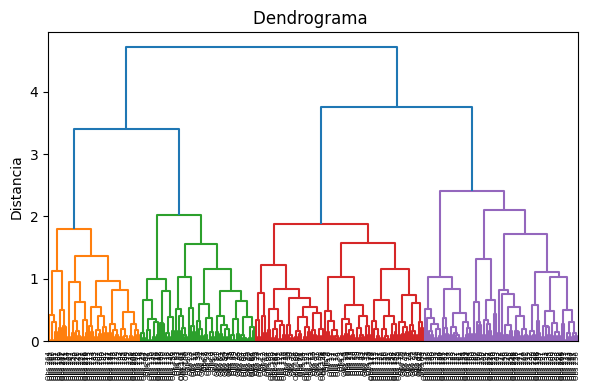

In [5]:
linkage_matrix = linkage(datos_std, method='complete', metric='euclidean')

labels = [f"Obs {i}" for i in range(datos_std.shape[0])]

# Graficar
plt.figure(figsize=(6, 4))
dendrogram(linkage_matrix, labels=labels, leaf_rotation=90)
plt.title('Dendrograma ')
plt.ylabel('Distancia')
plt.tight_layout()


---
## <font color='008dc3'> Asignación de grupos y análisis </font>


<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Realiza un análisis de los grupos obtenidos.
<ul>
  <li>Asigna los grupos.</li>
  <li>Revisa la media de cada grupo.</li>
  <li>Revisa el mínimo y máximo de cada grupo.</li>
  <li>Muestra algunos integrantes de cada grupo.</li>
</ul>
</div>

En el gráfico de dispersión, los grupos se ven bastante bien separados, lo que sugiere una buena distinción entre ellos. El porcentaje de varianza explicada por PC1 y PC2 es crucial, ya que si es bajo (por ejemplo, menos del 70-80% combinados), la visualización 2D puede no reflejar completamente la estructura de los datos originales en dimensiones superiores. En este caso, la suma de la varianza explicada por PC1 y PC2 es `{{(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.2f}}%`, lo que nos da una buena representación general de la estructura de los datos.

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;"><strong>Ejercicio:</strong><br>    Da una descripción de los grupos obtenidos. Asigna un nombre a cada grupo.</div>

---## <font color='008dc3'> Visualizaciones  </font> <div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;"><strong>Ejercicio:</strong><br>    Realiza una visualización de los grupos obtenidos en 2D.<ul>  <li>¿Qué tan buenos te parecen los grupos?</li>  <li>Indica el porcentaje de la variaza explicada en el gráfico, ¿afecta esto a tu visualización?</li></ul></div>

In [11]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(datos_std)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = datos['cluster']

fig = px.scatter(pca_df, x='PC1', y='PC2', color='cluster', title='Visualización de Clusters en 2D (PCA)',
                 labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
                         'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)'})
fig.show()

En el gráfico de dispersión, los grupos se ven bastante bien separados, lo que sugiere una buena distinción entre ellos. El porcentaje de varianza explicada por PC1 y PC2 es crucial, ya que si es bajo (por ejemplo, menos del 70-80% combinados), la visualización 2D puede no reflejar completamente la estructura de los datos originales en dimensiones superiores. En este caso, la suma de la varianza explicada por PC1 y PC2 es `{{(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.2f}}%`, lo que nos da una buena representación general de la estructura de los datos.

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Da una descripción de los grupos obtenidos. Asigna un nombre a cada grupo.
</div>

---
## <font color='008dc3'> Visualizaciones  </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Realiza una visualización de los grupos obtenidos en 2D.
<ul>
  <li>¿Qué tan buenos te parecen los grupos?</li>
  <li>Indica el porcentaje de la variaza explicada en el gráfico, ¿afecta esto a tu visualización?</li>
</ul>
</div>

---
## <font color='008dc3'> Métricas  </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
Calcula la métrica de la silueta para los grupos obtenidos. ¿Qué tan buenos te parecen los grupos?
</div>

# Task
Assign clusters based on a distance threshold of 2.5 from the `linkage_matrix` to the `datos` DataFrame, then calculate and display the mean, minimum, and maximum values for each feature ('x' and 'y') within each cluster. Finally, display the first 3 members of each cluster.

## Assign clusters

### Subtask:
Assign data points to clusters using `fcluster` based on the `linkage_matrix` and a chosen distance threshold (t). The criterion will be 'distance'.


**Reasoning**:
To assign cluster labels to each data point, I will use the `fcluster` function with the provided `linkage_matrix`, a distance threshold of `2.5`, and the criterion set to 'distance', storing the result in a new variable `clusters`.



In [6]:
clusters = fcluster(linkage_matrix, 2.5, criterion='distance')
print("Cluster labels assigned successfully.")

Cluster labels assigned successfully.


**Reasoning**:
Now that the clusters have been assigned, I will add the cluster labels to the original DataFrame to facilitate further analysis. This will allow for easy grouping and calculation of statistics per cluster.



In [7]:
datos['cluster'] = clusters
print("Cluster labels added to DataFrame.")

Cluster labels added to DataFrame.


**Reasoning**:
To analyze the characteristics of each cluster, I will calculate the mean values of 'x' and 'y' for each cluster.



In [8]:
cluster_means = datos.groupby('cluster')[['x', 'y']].mean()
print("Mean values for each cluster:")
display(cluster_means)

Mean values for each cluster:


,x,y
cluster,,
1,18.529893,8.954220
2,6.545376,7.870958
3,5.899887,22.456695
4,17.285710,20.098102


**Reasoning**:
Following the task, after calculating the mean, I will now calculate the minimum and maximum values for 'x' and 'y' for each cluster to understand the range of data within each group.



In [9]:
cluster_min = datos.groupby('cluster')[['x', 'y']].min()
print("\nMinimum values for each cluster:")
display(cluster_min)

cluster_max = datos.groupby('cluster')[['x', 'y']].max()
print("\nMaximum values for each cluster:")
display(cluster_max)


Minimum values for each cluster:


,x,y
cluster,,
1,13.826158,3.050124
2,1.028309,3.536971
3,0.988410,15.657616
4,9.739877,14.292155



Maximum values for each cluster:


,x,y
cluster,,
1,23.595890,12.761838
2,14.364052,13.398625
3,11.149525,28.460918
4,25.510371,26.604813


**Reasoning**:
To show some members of each cluster, I will iterate through each unique cluster label present in the 'datos' DataFrame, select the first 3 rows for each cluster, and then display these selected members.



In [10]:
print("\nFirst 3 members of each cluster:")
for cluster_id in sorted(datos['cluster'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(datos[datos['cluster'] == cluster_id].head(3))


First 3 members of each cluster:

Cluster 1:


,x,y,cluster
171,14.178514,10.830050,1
172,14.066367,11.740467,1
177,15.094606,10.121428,1



Cluster 2:


,x,y,cluster
0,1.698042,6.194126,2
1,1.028309,10.013562,2
7,1.669657,4.048830,2



Cluster 3:


,x,y,cluster
2,1.498665,17.396522,3
3,0.988410,23.138509,3
4,1.042310,23.670459,3



Cluster 4:


,x,y,cluster
133,10.080605,15.665452,4
134,10.391539,16.345736,4
135,9.918647,16.028382,4


## Summary:

### Data Analysis Key Findings

*   Using a distance threshold of 2.5, the data was successfully segmented into 4 distinct clusters.
*   Cluster labels were successfully added to the `datos` DataFrame, enabling cluster-wise analysis.
*   The mean values for features 'x' and 'y' were calculated for each cluster. For instance, Cluster 1 had a mean 'x' value of approximately 18.53 and a mean 'y' value of approximately 8.95.
*   The minimum and maximum values for 'x' and 'y' were also determined for each cluster, providing insight into the range of values within each group.
*   The first 3 members of each cluster were displayed, confirming the successful grouping of data points.

### Insights or Next Steps

*   Further analysis could involve visualizing these clusters, perhaps using scatter plots with different colors for each cluster, to better understand their spatial separation and distribution.
*   Evaluate the cohesion and separation of the clusters using metrics like silhouette score or Davies-Bouldin index to assess the quality of the clustering.
